# Datasets Preparation

START DATASETS PREPARATION
verbose is True
>> imports
>> load trajectories


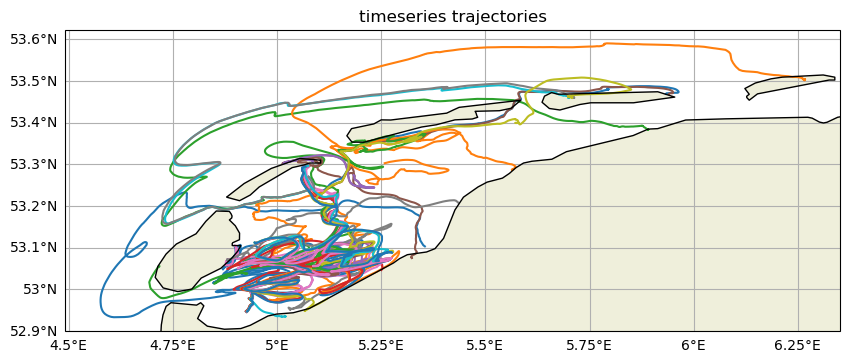

>> load bathymetry
imshow gives 2nd index on X axis and 1st index on Y axis
squares : show orientation of data. darkest is origin, middle is 1st index max, brigthest is 2nd index max
(10139, 5185)
[4.3813815 4.3816843 4.3819876 ... 7.4529176 7.453221  7.4535236]
10139
[52.79103  52.791214 52.791397 ... 53.739372 53.739555 53.73974 ]
5185


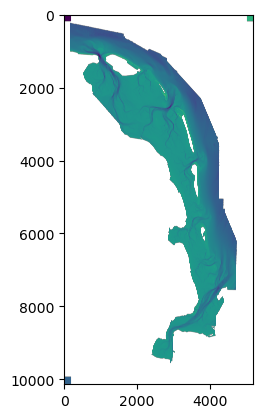

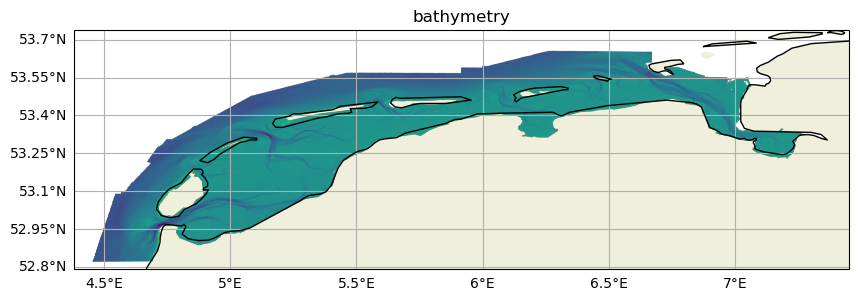

>> load waterlevel
structure before parsing
dict_keys(['time', 'set'])
dict_keys(['lon', 'lat', 'level'])
structure after parsing
dict_keys(['times', 'lons', 'lats', 'vals'])


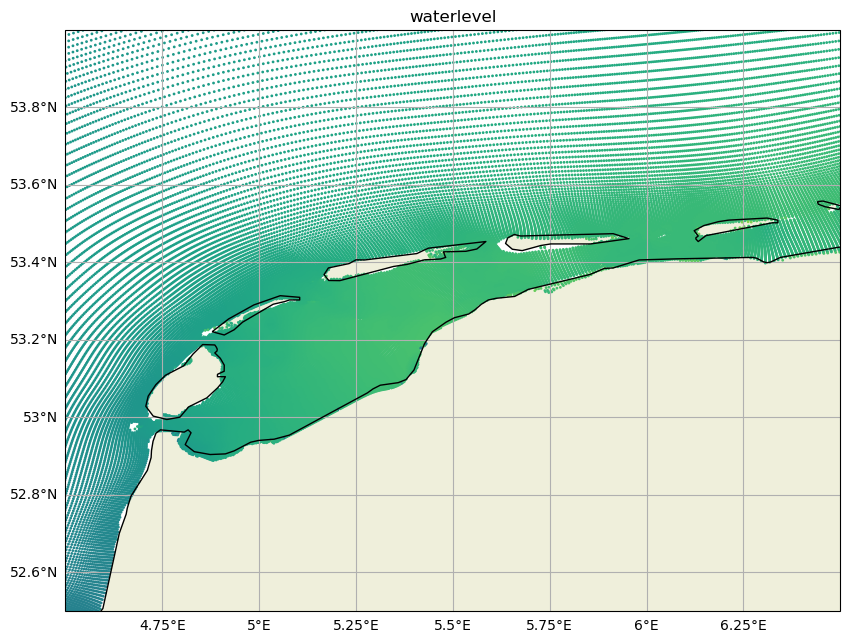

>> load wind
>> preprocessing bathymetry
resolution original dataset x~20.324686m and y~20.324707m
resolution downscaled x~101.718607m and y~101.623535m


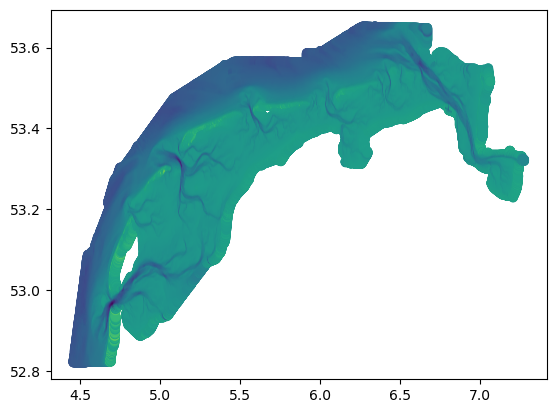

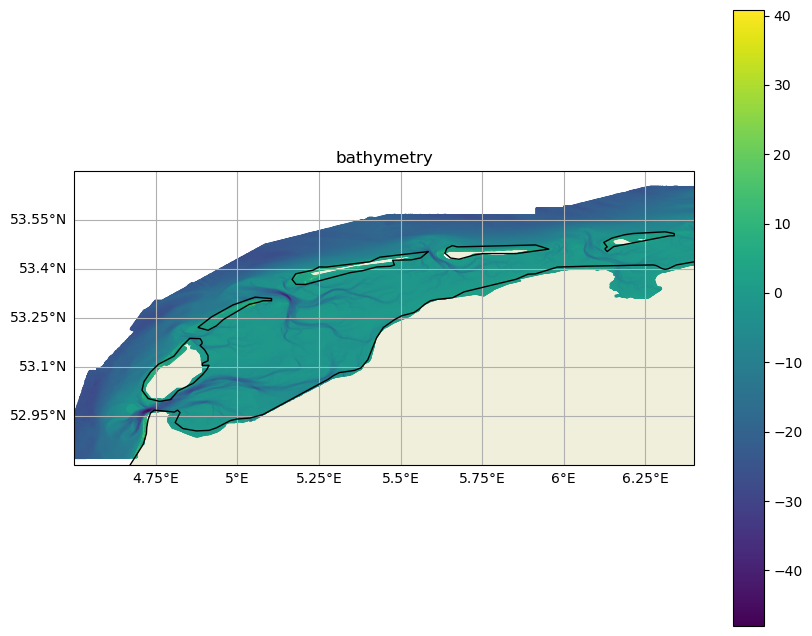

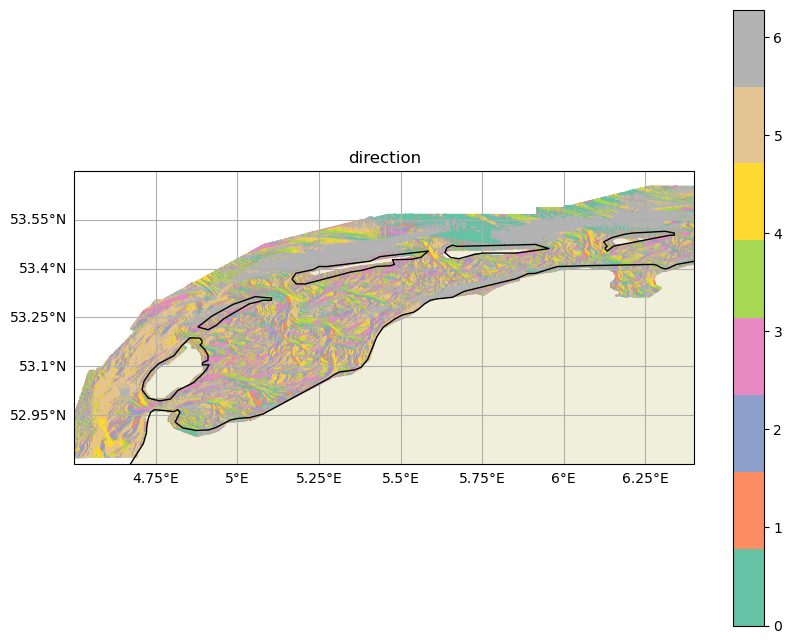

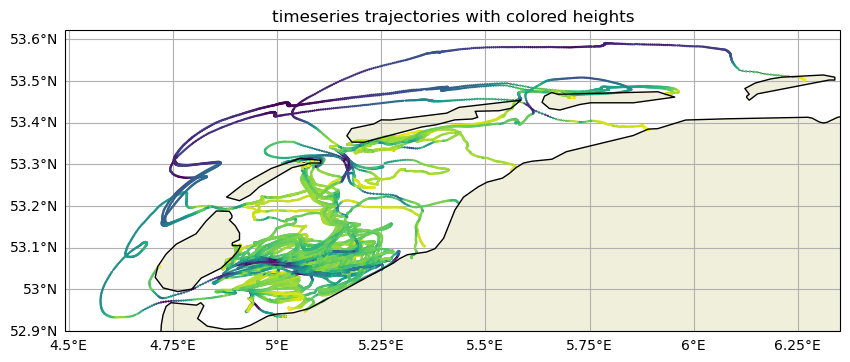

>> preprocessing wind
<xarray.DataArray 'valid_time' ()> Size: 8B
array('2023-11-01T00:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    number      int64 8B ...
    valid_time  datetime64[ns] 8B 2023-11-01
    expver      <U4 16B ...
Attributes:
    long_name:      time
    standard_name:  time


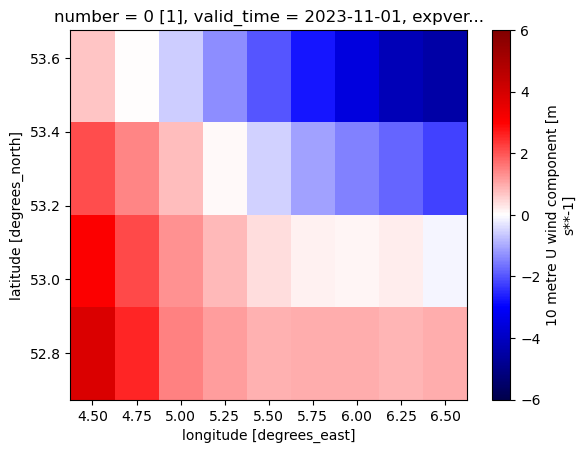

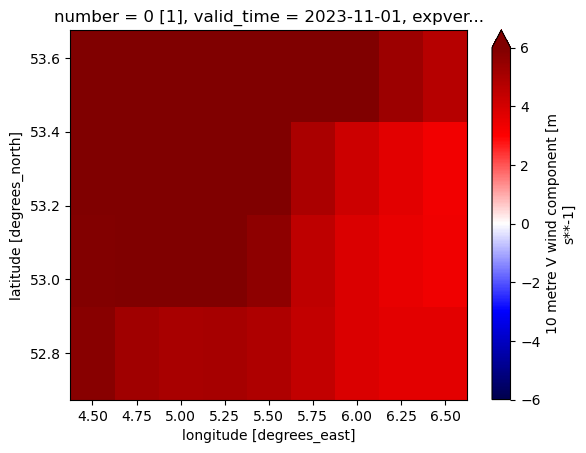

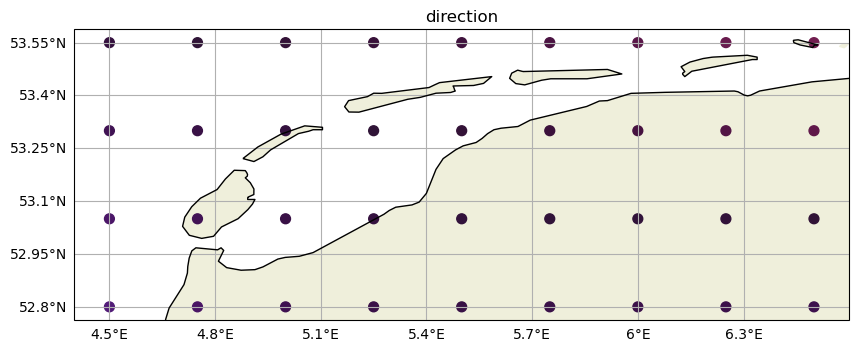

[9.86283273e-02 3.14844400e-01 4.73938286e-01 5.88199139e-01
 4.37219162e-03 2.01450020e-01 3.30025911e-01 4.51671809e-01
 6.20580578e+00 1.02269500e-01 1.97678313e-01 2.89350301e-01
 6.11628485e+00 1.05228387e-02 1.30931467e-01 2.19666779e-01
 6.02238464e+00 6.19804525e+00 6.72390461e-02 1.85046032e-01
 5.89434338e+00 6.06714582e+00 3.33250314e-02 2.14398876e-01
 5.75142384e+00 5.93979311e+00 2.90516745e-02 2.40780577e-01
 5.61669588e+00 5.82316828e+00 5.40761761e-02 2.38645166e-01
 5.52496576e+00 5.68720484e+00 6.24868631e+00 2.62457132e-01]


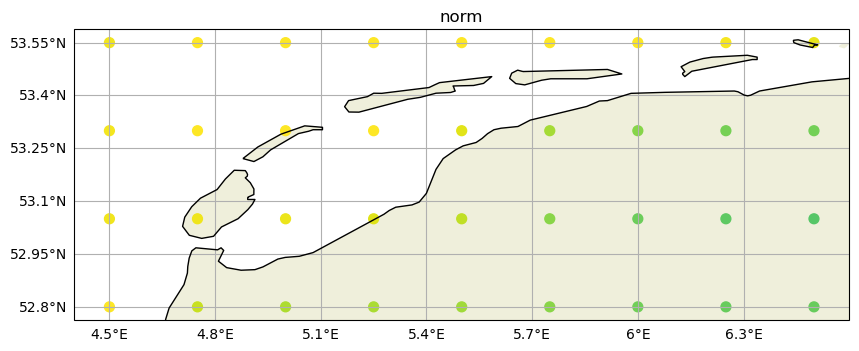

[6.71786451 6.73721266 6.68800879 6.956635   7.28684902 7.11897564
 6.62243795 5.81362534 7.85300255 7.4145093  6.57547998 5.25065756
 8.04975891 7.08795309 6.34203911 5.20594501 7.75583982 6.35778236
 5.65943146 4.99249601 7.27849197 5.13365507 4.50265837 4.51365709
 6.94428873 4.44833803 3.8535912  3.96575832 6.79765081 4.09436798
 3.53449965 3.75991583 6.50285578 3.99949074 3.33026505 3.77190375]
>> defining misc shared methods
DONE DATASETS PREPARATION


In [1]:
%run ./2_0_datasets_preparation.ipynb

# Parameters

In [2]:
verbose = True
plot_dir = "plot/"

# Parameters

In [3]:
samp = { # sampling parameters
    'surroundings_distance_meters' : 1000.,
    't': [1699920000,1701388800], # time interval in epoch timestamps
    'p': {
        'CT': [5.242308390, 53.216548680],
        'NW': [4.967661231, 52.990785512],
        'SE': [5.622440284, 53.369652522]
    },
}

# 1: Plots

### Wind and Sea conditions

INFO: all wind speeds below defined max value 18.000000m/s
N = 409 sum histo counts = 409
[[17. 30. 13.  5.  9. 18. 26. 31.]
 [18. 21.  7.  5. 26. 21. 49. 18.]
 [13.  1.  3.  3.  2.  2. 41. 30.]]
[11.73594132 12.71393643  5.62347188  3.17848411  9.04645477 10.02444988
 28.36185819 19.31540342]
[12.71393643  5.62347188  3.17848411  9.04645477 10.02444988 28.36185819
 19.31540342]


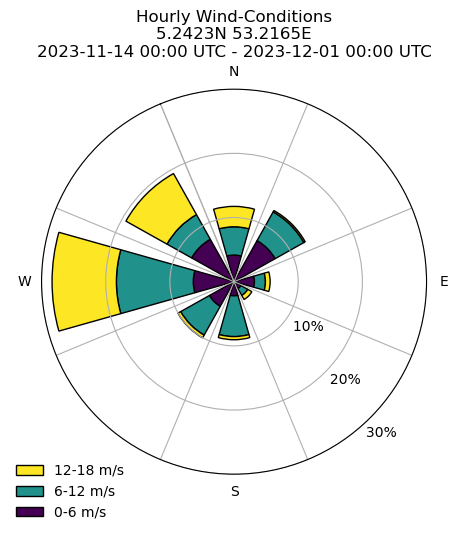

In [21]:
dt_h = 1 # sampling timesteps

from datetime import datetime
import pytz

def sample_cmap_rgb(v, vrange=[0.0,1.0], cmap_str='viridis'):
  cmap = mpl.colormaps.get_cmap(cmap_str)
  norm = mpl.colors.Normalize(vmin=vrange[0],vmax=vrange[1])
  rgb = cmap(norm(v))[:3]
  return rgb

def get_wind_ts(dt_h=1, wind_direction_angle=False):
  times_sample = np.array(range(samp['t'][0],samp['t'][1]+1,60*60*dt_h))
  wind_direction = np.zeros(times_sample.shape[0])
  wind_speed = np.zeros(times_sample.shape[0])
  for it, t in enumerate(times_sample):
    wind_direction[it], wind_speed[it], _, _ = get_wind_conditions(samp['p']['CT'][0], samp['p']['CT'][1], t)
  if wind_direction_angle:
    wind_direction = (wind_direction+np.pi)%(2*np.pi)
  N = len(times_sample)
  return times_sample, wind_direction, wind_speed, N

# read wind data and compute histogram bins

alp_labels = ["N","NE","E","SE","S","SW","W","NW"]
alp_labels_short = ["N","","E","","S","","W",""]
alp_lims = np.array([1,3,5,7,9,11,13,15]) * (2.*np.pi)/16.
v_labels = ["0-6 m/s","6-12 m/s","12-18 m/s"]
v_lims = np.array([6.,12.,18])

t, alp, v, N = get_wind_ts(dt_h, True)
if np.sum(v_lims[-1]>18):
  print("WARNING: wind speed above defined max value %fm/s" % v_lims[-1])
else:
  print("INFO: all wind speeds below defined max value %fm/s" % v_lims[-1])

histo_wind_alp_v = np.zeros((3,8))
for i in range(N):
  bin_alp,bin_v = 0,0
  for ilim, lim in enumerate(alp_lims):
    if(alp[i]<lim):
      bin_alp = ilim
      break
  for ilim, lim in enumerate(v_lims):
    if(v[i]<lim):
      bin_v = ilim
      break
  histo_wind_alp_v[bin_v,bin_alp] += 1

print("N = %d sum histo counts = %d"%(N, np.sum(histo_wind_alp_v)))
print(histo_wind_alp_v)

print(np.sum(histo_wind_alp_v,axis=0)/N*100)
print(np.array([np.sum(((2.*np.pi)*(1.+2.*i)/16.<alp)*(alp<(2.*np.pi)*(1.+2.*(i+1))/16.))/N*100 for i in range(7)]))

data_plot_histo_wind_alp_v = [[] for _ in range(3)]
for iv in range(3):
  for id,cntd in enumerate(histo_wind_alp_v[iv]):
    data_plot_histo_wind_alp_v[iv] += [id*(2.*np.pi)/8.]*((int)(cntd))

# plotting

figsize_xy=5
fig, ax = plt.subplots(subplot_kw=dict(projection="polar"),figsize=(figsize_xy,figsize_xy))

ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)
xrange = [-1./16.*(2.*np.pi), 15./16.*(2.*np.pi)]
ax.set_xlim(xrange)

ax.set_rlabel_position(145)
ax.set_xticks(np.linspace(xrange[0],xrange[1],8+1),['','','','','','','','',''])
ax.set_xticks(alp_lims-1./16.*(2.*np.pi), labels=alp_labels_short, minor=True)
ax.set_yticks(np.array(range(10,30+1,10))/100*N,["     %d%%"%p for p in range(10,30+1,10)])
ax.set_ylim(0,30./100.*N)

colors_hist = [sample_cmap_rgb(v,[0,18.]) for v in [0,9,18]]
mpl.rcParams['hatch.linewidth'] = 1

ax.hist(data_plot_histo_wind_alp_v, bins=8, range=xrange, color=colors_hist, zorder=-10, histtype="barstacked", edgecolor='black',linewidth=1, rwidth=0.7, label=v_labels)
#ax.hist(data_hist, bins=n_bins, range=x_range, color=colors_hist, zorder=-10, histtype="barstacked", hatch=hatching_hist, edgecolor='white',linewidth=1, label=categories_labels[category]*len(histo_labels)) #, histtype="barstacked", stacked=True
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], loc="lower left", frameon=False,bbox_to_anchor=(-0.1,-0.15)) #,ncols=3, prop={'size': 8},bbox_to_anchor=(0.5,-0.25)

s_t0 = datetime.fromtimestamp(samp['t'][0],pytz.utc).strftime('%Y-%m-%d %H:%M UTC')
s_t1 = datetime.fromtimestamp(samp['t'][1],pytz.utc).strftime('%Y-%m-%d %H:%M UTC')
plt.title("Hourly Wind-Conditions\n%.4fN %.4fE\n%s - %s" % (samp['p']['CT'][0],samp['p']['CT'][1],s_t0,s_t1))
plt.draw()
fig.savefig(plot_dir+'campaign/wind_conditions.png', dpi=300, bbox_inches="tight")
plt.show()

### Validation

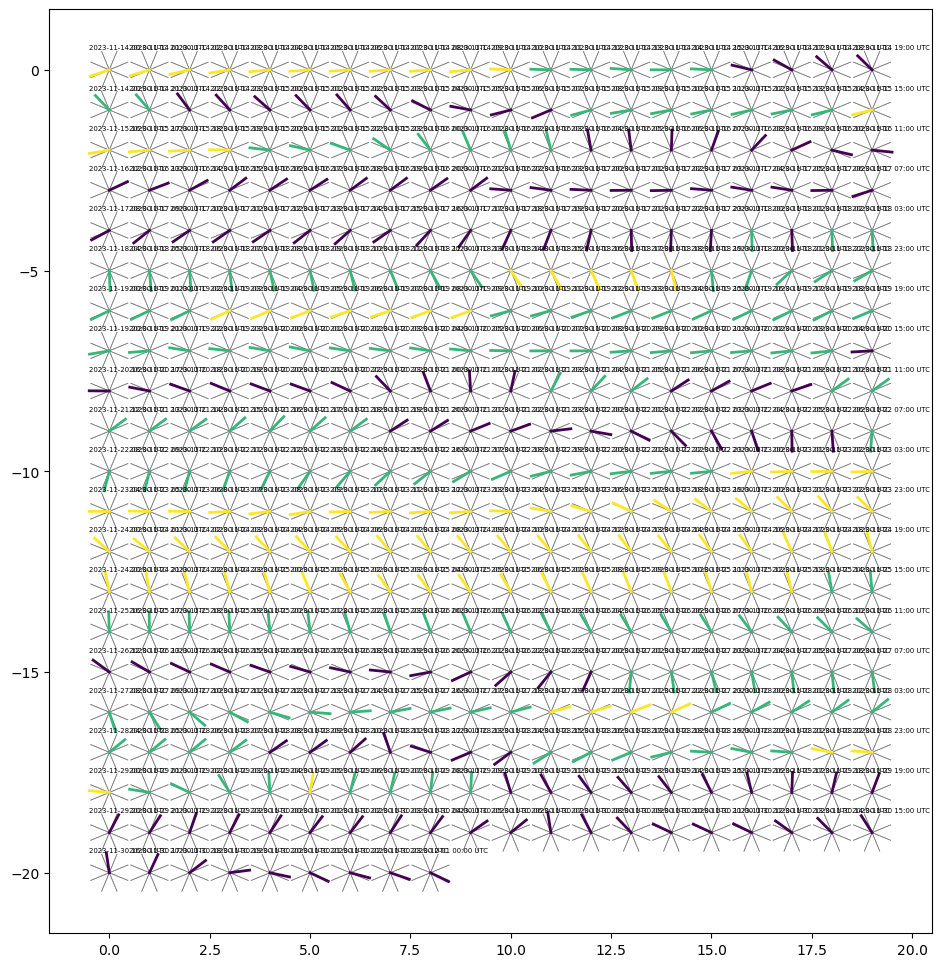

In [5]:
from datetime import datetime
import pytz

t, alp, v, N = get_wind_ts(dt_h, True)
bet = np.pi/2.-alp
fig, (ax) = plt.subplots(1,1,figsize=(12,12))
vsc = np.ones(N) * 12
vsc[v<6] = 0
vsc[v>12] = 18
color = [sample_cmap_rgb(vsc[i], [0,18.]) for i in range(N)]
ax.axes.set_aspect('equal')
intSqrtN = int(np.sqrt(N))
ln = 0.5
for i in range(N):
  x0, y0 = i%intSqrtN, -int(i/intSqrtN)
  for idir in range(8):
    ang = idir*np.pi/4.+np.pi/8.
    ax.plot([x0-ln*np.cos(ang),x0+ln*np.cos(ang)],[y0-ln*np.sin(ang),y0+ln*np.sin(ang)],c='grey',lw=0.5)
  ax.plot([x0,x0+ln*np.cos(bet[i])],[y0,y0+ln*np.sin(bet[i])],c=color[i],lw=2)
  ax.text(x0-ln, y0+ln, datetime.fromtimestamp(t[i],pytz.utc).strftime('%Y-%m-%d %H:%M UTC'), fontsize=5)

### Water levels

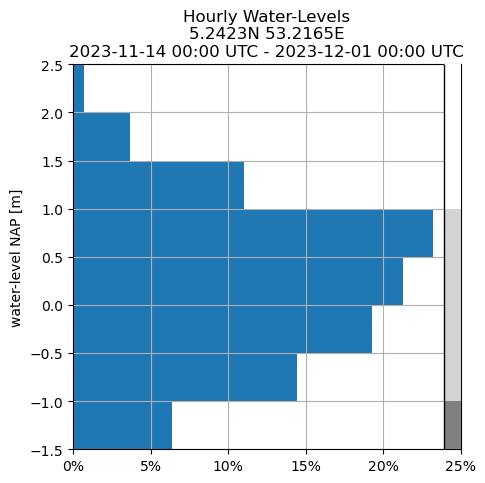

In [18]:

times_sample = np.array(range(samp['t'][0],samp['t'][1]+1,60*60))
water_level = np.zeros(times_sample.shape[0])
for it, t in enumerate(times_sample):
  water_level[it] = utils.sample_nearest_mesh_value(swanwaterlevel,{"lon":samp['p']['CT'][0], "lat":samp['p']['CT'][1], "time":t})[0]
colors_bathymetry = ['white','lightgrey','grey','black']
fig, ax = plt.subplots(figsize=(figsize_xy,figsize_xy))
plt.title("Hourly Water-Levels\n%.4fN %.4fE\n%s - %s" % (samp['p']['CT'][0],samp['p']['CT'][1],s_t0,s_t1))
wl_range = [-1.5,2.5]
N = water_level.shape[0]
ax.hist(water_level,bins=8,range=wl_range, orientation='horizontal')
ax.set_ylim(wl_range)
pmax_xaxis = 25
ax.set_xlim([0,pmax_xaxis])
ax.set_xticks(np.array(range(0,pmax_xaxis+1,5))/100*N,["%d%%"%p for p in range(0,pmax_xaxis+1,5)])
ax.bar(98,-1.5,5,color=colors_bathymetry[2],align='edge',zorder=10)
ax.bar(98,2.5,5,color=colors_bathymetry[0],align='edge',zorder=10)
ax.bar(98,1,5,color=colors_bathymetry[1],align='edge',zorder=10)
ax.bar(98,-1,5,color=colors_bathymetry[1],align='edge',zorder=10)
ax.vlines(98,-1.5,2.5,colors='black',lw=1,zorder=11)
ax.vlines(103,-1.5,2.5,colors='black',lw=1,zorder=11)
ax.set_ylabel("water-level NAP [m]")
plt.grid(zorder=100)
plt.draw()
fig.savefig(plot_dir+'campaign/waterlevels.png', dpi=300)
plt.show()

### Campaign overview

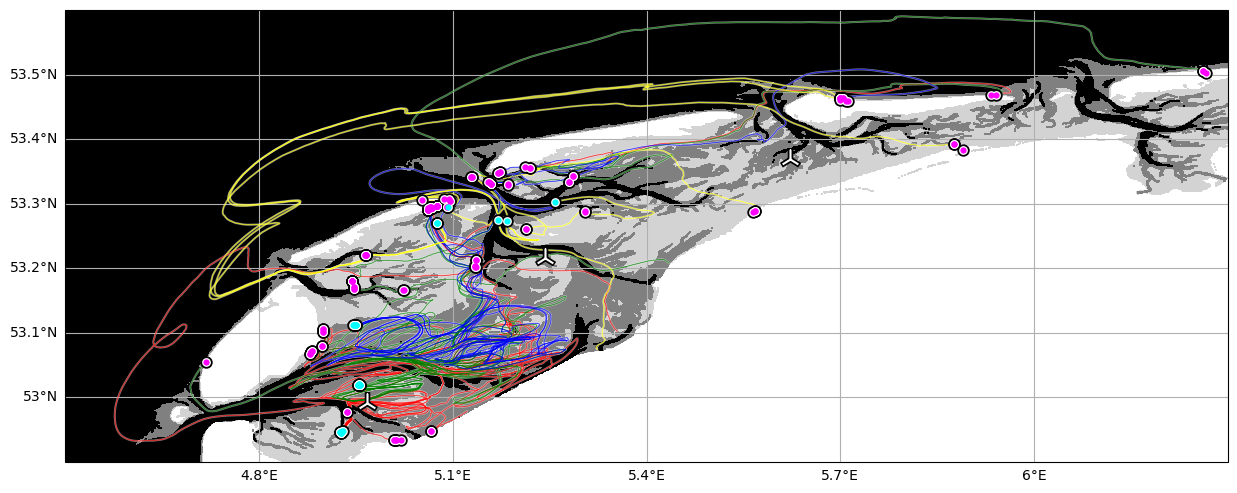

<Figure size 32000x24000 with 0 Axes>

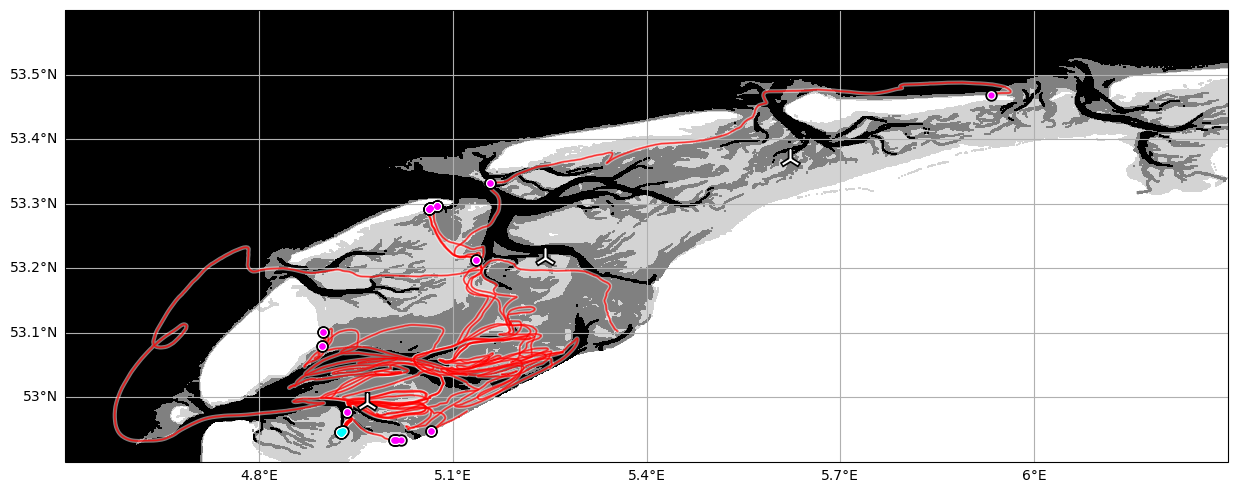

<Figure size 32000x24000 with 0 Axes>

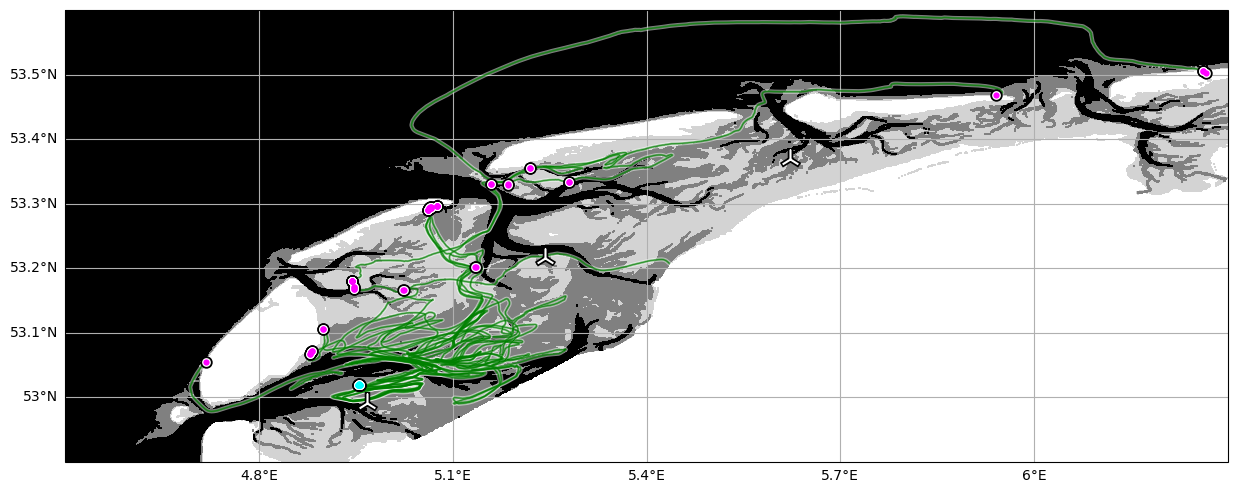

<Figure size 32000x24000 with 0 Axes>

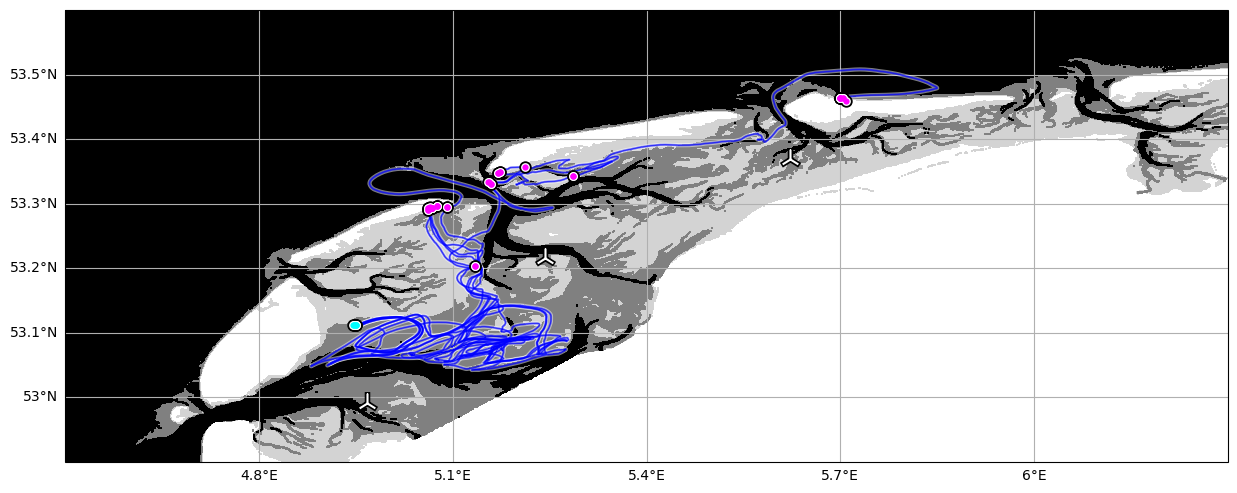

<Figure size 32000x24000 with 0 Axes>

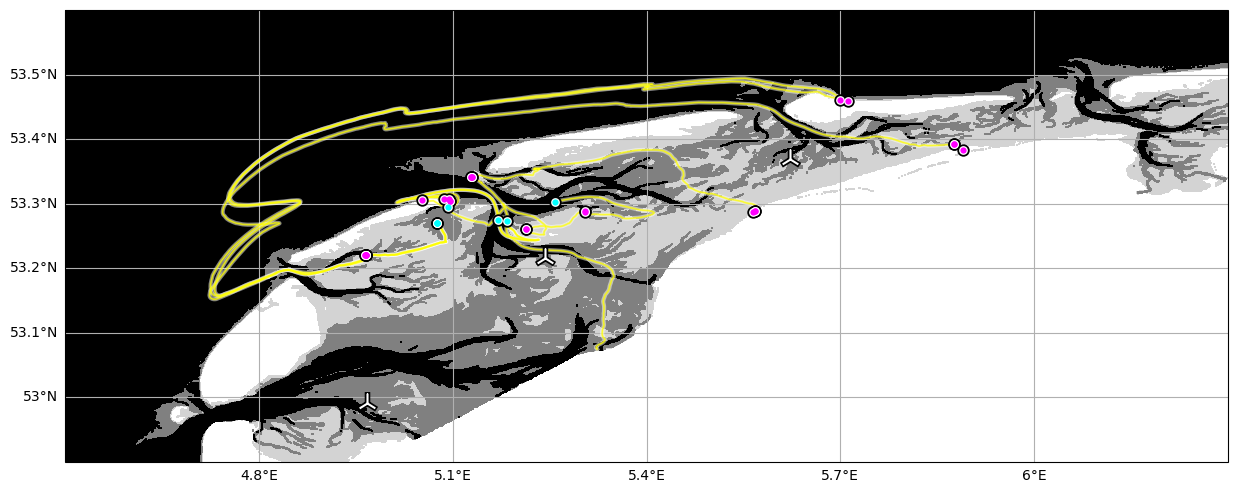

<Figure size 32000x24000 with 0 Axes>

In [6]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import colorsys

groups = {
  'A':{
    'A1':[[0],[1],[3]],
    'A2':[[4],[6],[7]],
    'A3':[[8],[9],[10]],
  },
  'B':{
    'B1':[[11],[12],[13]],
    'B2':[[14],[15]],
    'B3':[[16,17],[18],[20]],
  },
  'C':{
    'C1':[[28],[29],[30]],
    'C2':[[22],[23],[26]],
  },
  'D':{
    'D1':[[2],[5],[19],[21],[24],[27]],
  },
  'E':{
    'E1':[[25]],
  }
}

group_sets = [
  {'group':{
    'A':groups['A'],
    'B':groups['B'],
    'C':groups['C'],
    'D':groups['D'],
    'E':groups['E']
  },'trajectories_width':1},
  {'group':{
    'A':groups['A']
  },'trajectories_width':2},
  {'group':{
    'B':groups['B']
  },'trajectories_width':2},
  {'group':{
    'C':groups['C']
  },'trajectories_width':2},
  {'group':{
    'D':groups['D'],
    'E':groups['E']
  },'trajectories_width':2}
]

dhue = 0
def hue_from_deg(hue_deg):
  return (hue_deg%360)/360.
colors_wsc = {
  'A':colorsys.hsv_to_rgb(hue_from_deg(0),1,1),#'red',
  'B':colorsys.hsv_to_rgb(hue_from_deg(120),1,0.5),#'green',
  'C':colorsys.hsv_to_rgb(hue_from_deg(240),1,1),#'blue',
  'D':colorsys.hsv_to_rgb(hue_from_deg(60),1,1),#'yellow',
  'E':colorsys.hsv_to_rgb(hue_from_deg(60),1,1),#'yellow',
  'A1':colorsys.hsv_to_rgb(hue_from_deg(0-dhue),1,1),
  'A2':colorsys.hsv_to_rgb(hue_from_deg(0),1,1),
  'A3':colorsys.hsv_to_rgb(hue_from_deg(0+dhue),1,1),
  'B1':colorsys.hsv_to_rgb(hue_from_deg(120-dhue),1,0.5),
  'B2':colorsys.hsv_to_rgb(hue_from_deg(120),1,0.5),
  'B3':colorsys.hsv_to_rgb(hue_from_deg(120+dhue),1,0.5),
  'C1':colorsys.hsv_to_rgb(hue_from_deg(240-dhue/2),1,1),
  'C2':colorsys.hsv_to_rgb(hue_from_deg(240+dhue/2),1,1),
  'D1':colorsys.hsv_to_rgb(hue_from_deg(60-dhue/2),1,1),
  'E1':colorsys.hsv_to_rgb(hue_from_deg(60+dhue/2),1,1),
}

extent_wsc=[[4.5,6.3],[52.9,53.6]]
mkr = 'o'
for gs in group_sets:
  fig, ax = utils.map_plot("", figsize=(15,15), add_land_coastline=[False,False], extent=extent_wsc, grid_ticks=[7,8])
  plt.figure(dpi=5000)
  for group_key in gs['group'].keys(): #colors_wsc[group_key]
    twidth = gs['trajectories_width']
    for subgroup_key in groups[group_key].keys(): #colors_wsc[subgroup_key]
      for g in groups[group_key][subgroup_key]:
        size, scale = 20, 2
        release_lon, release_lat = trajectories[g[0]].lon.values[0], trajectories[g[0]].lat.values[0]
        ax.scatter(release_lon, release_lat, s=size*scale*2,c='black', marker=mkr,linewidths=0, zorder=18)
        ax.scatter(release_lon, release_lat, s=size*scale,c='w', marker=mkr,linewidths=0, zorder=19)
        ax.scatter(release_lon, release_lat, s=size,c='cyan', marker=mkr,linewidths=0, zorder=20)
        for it in g:
          inds = (trajectories[it].label.values==-1.0)+(trajectories[it].label.values==1.0)
          lons, lats = trajectories[it].lon.values[inds], trajectories[it].lat.values[inds]
          ax.scatter(lons, lats, s=size*scale*2,c='black', marker=mkr,linewidths=0, zorder=18)
          ax.scatter(lons, lats, s=size*scale,c='w', marker=mkr,linewidths=0, zorder=19)
          ax.scatter(lons, lats, s=size,c='magenta', marker=mkr,linewidths=0, zorder=20)
        for it in g:
          ax.plot(trajectories[it].lon.values, trajectories[it].lat.values,lw=1.5*twidth,color='w', zorder=9,alpha=0.5)
          ax.plot(trajectories[it].lon.values, trajectories[it].lat.values,lw=0.8*twidth,color=colors_wsc[subgroup_key], zorder=10,alpha=0.5)
          ax.plot(trajectories[it].lon.values, trajectories[it].lat.values,lw=0.2*twidth,color=colors_wsc[subgroup_key], zorder=10,alpha=1)

  heights = [np.inf,1.0,-1.0,-5.0,-np.inf]
  colors = ['white','lightgrey','grey','black']
  for i in range(len(heights)-1):
    range_max, range_min = heights[i], heights[i+1]
    inds = (range_min<=vals_mesh)*(vals_mesh<range_max)
    ax.scatter(bathymetry["lons"][inds], bathymetry["lats"][inds], transform=ccrs.PlateCarree(), zorder=-10,marker='s',s=1.5,linewidths=0,color=colors[i])
    ax.fill([4.5,4.8,5.25,6.3,4.5], [52.9,53.3,53.5,53.6,53.6], 'black', zorder=-11)

  ps = samp['p'].values()
  ax.scatter([p[0] for p in ps],[p[1] for p in ps],lw=4,marker='2',s=270,c='black',zorder=30)
  ax.scatter([p[0] for p in ps],[p[1] for p in ps],lw=1.5,marker='2',s=200,c='white',zorder=31)

  plt.draw()
  fig.savefig(plot_dir+'campaign/campaignrecords_groups%s.png'%''.join(gs['group'].keys()), dpi=300)
  fig.savefig(plot_dir+'campaign/campaignrecords_groups%s.svg'%''.join(gs['group'].keys()))
  plt.show()

### Context map

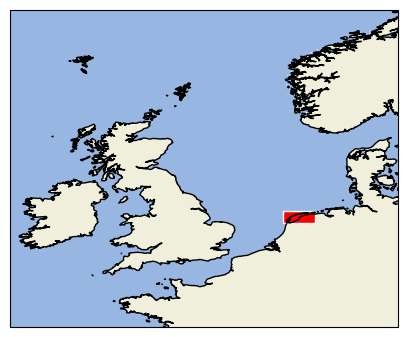

In [7]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.patches as patches

figsize=(5,5)
extent=[[-11,11],[47,65]]
grid_ticks=[0,0]

fig = plt.figure(figsize=figsize)
ax = plt.axes(projection=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE.with_scale('10m'),lw=1, zorder=20)
ax.add_feature(cfeature.OCEAN.with_scale('10m'), zorder=0)
ax.add_feature(cfeature.LAND.with_scale('10m'), zorder=0)
ax.set_xlim(extent[0])
ax.set_ylim(extent[1])
rect = patches.Rectangle((extent_wsc[0][0],extent_wsc[1][0]),extent_wsc[0][1]-extent_wsc[0][0],extent_wsc[1][1]-extent_wsc[1][0], linewidth=1, edgecolor='white', facecolor="r", zorder=10)
ax.add_patch(rect)

plt.draw()
fig.savefig(plot_dir+'campaign/campaignmap.png', dpi=300)
fig.savefig(plot_dir+'campaign/campaignmap.svg')
plt.show()

### Timeline

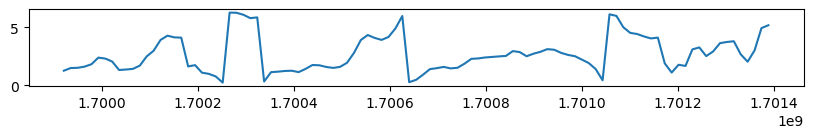

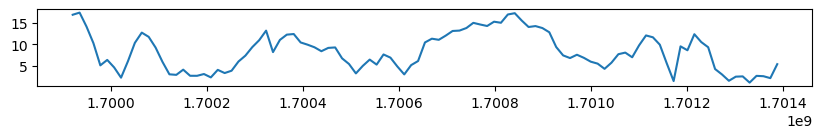

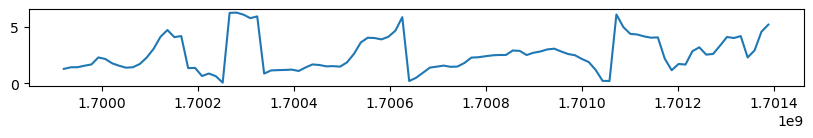

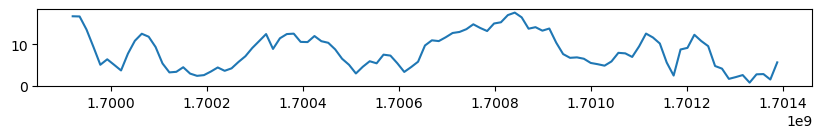

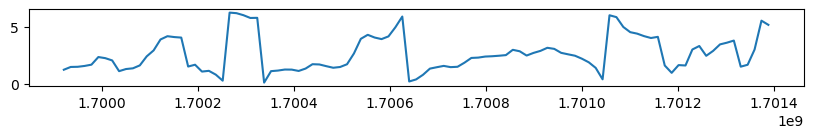

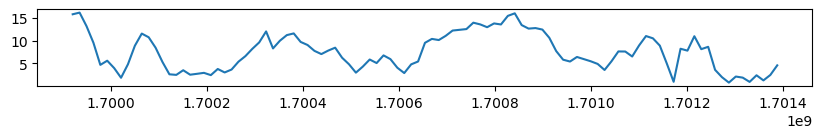

In [8]:
import utils

n_times_wind = 103 # = 17[d]*24[h/d]/4[h] +1
n_times_water = 409 # = 17[d]*24[h/d]/1[h] +1

times_wind = np.linspace(samp['t'][0],samp['t'][1],n_times_wind)
times_water = np.linspace(samp['t'][0],samp['t'][1],n_times_water)

water_level = []
wind_directions = []
wind_speeds = []
wind_U = []
wind_V = []
for ipos, pos in enumerate(samp['p'].values()):
  lon, lat = pos
  water_level += [np.array([utils.sample_nearest_mesh_value(swanwaterlevel,{"lon":lon, "lat":lat, "time":t})[0] for t in times_water])]
  wind_directions += [np.array([get_wind_conditions(lon, lat, t)[0] for t in times_wind])]
  wind_speeds += [np.array([get_wind_conditions(lon, lat, t)[1] for t in times_wind])]
  wind_U += [np.array([get_wind_conditions(lon, lat, t)[2] for t in times_wind])]
  wind_V += [np.array([get_wind_conditions(lon, lat, t)[3] for t in times_wind])]
  if verbose:
    plt.figure(figsize=(10,1))
    plt.plot(times_wind,wind_directions[-1])
    plt.show()
    plt.figure(figsize=(10,1))
    plt.plot(times_wind,wind_speeds[-1])
    plt.show()


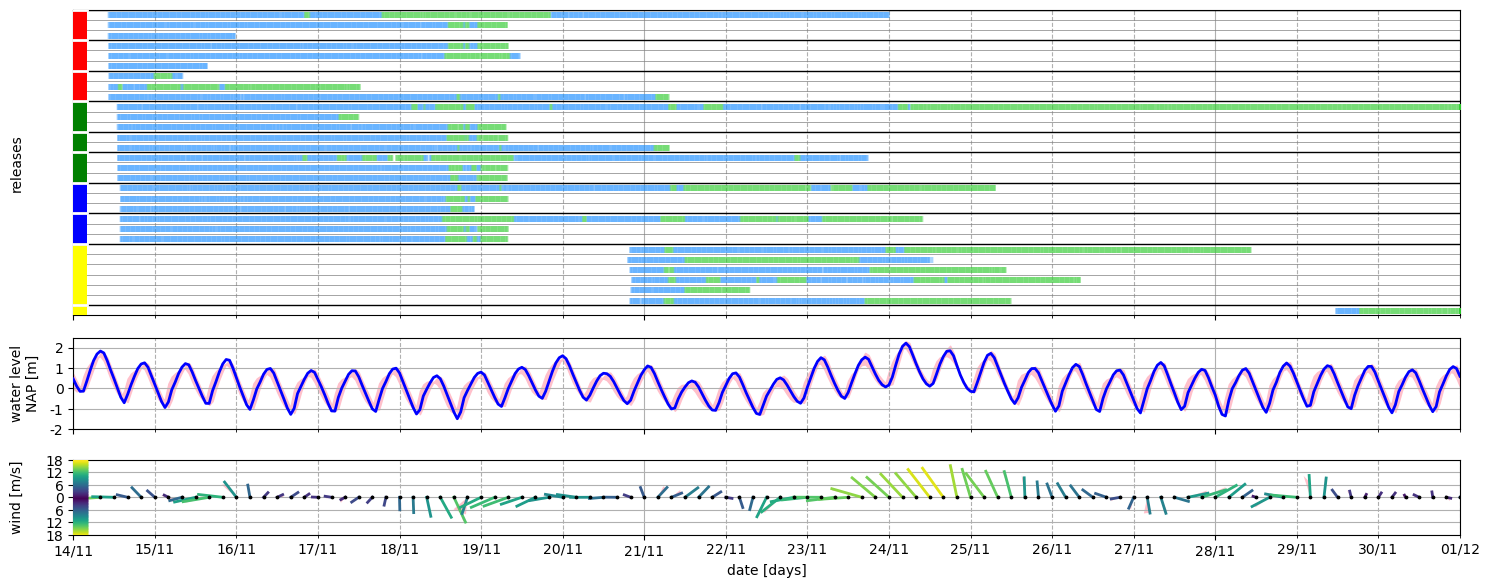

In [ ]:
# plotting parameters
ratio_ylim_xlim = 20
wind_speed_max_length = 0.027
figure_scale = 15
label_color = {'W':['dodgerblue','lightskyblue','lightcyan','w'],'D':['limegreen','lightgreen','honeydew','w'],'B':['darkgoldenrod','tan','antiquewhite','w']}

import matplotlib.patches as patches
from scipy.interpolate import interp1d
import matplotlib

def sample_cmap_rgb(v, vrange=[0.0,1.0], cmap_str='viridis'):
  cmap = matplotlib.colormaps.get_cmap(cmap_str)
  norm = matplotlib.colors.Normalize(vmin=vrange[0],vmax=vrange[1])
  rgb = cmap(norm(v))[:3]
  return rgb

time_min,time_max = samp['t']
xlim = 1
xticks = [interp1d(samp['t'],[0,xlim])(t) for t in range(time_min,time_max+1,604800)] #604800 s_per_week
xmticks = [interp1d(samp['t'],[0,xlim])(t) for t in range(time_min,time_max+1,86400)] #86400 s_per_day
times_wind_rescaled = interp1d([time_min,time_max],[0,xlim])(times_wind)
times_water_rescaled = interp1d([time_min,time_max],[0,xlim])(times_water)
wind_speed_min, wind_speed_max = np.floor(np.min(wind_speeds)), np.ceil(np.max(wind_speeds))

xwidth = xlim
ywidth = xlim/ratio_ylim_xlim
xrange = [0.0, xwidth]
yrange = [-0.5*ywidth, 0.5*ywidth]
figure_size_xy = [xwidth*figure_scale, ywidth*figure_scale]

fig, (axtimeline, axwaterlvl, axwind) = plt.subplots(3,1,height_ratios=[5,1.5,1.5])
fig.set_size_inches(figure_size_xy[0],figure_size_xy[1]*8)

# timeline groundings

cnt_max=30 # number of lines
axtimeline.set_xlim(xrange)
axtimeline.set_xticks(xticks)
axtimeline.set_xticks(xmticks, minor=True)
axtimeline.set_xticklabels([])
axtimeline.set_yticks([])
axtimeline.set_yticklabels([])
axtimeline.set_ylim([0,cnt_max])
cnt=0
axtimeline.set_ylim([0,cnt_max])
for igroup, group_key in enumerate(groups.keys()): #colors_wsc[group_key]
  for isubgroup, subgroup_key in enumerate(groups[group_key].keys()):
    axtimeline.plot([xrange[0],0.01],[cnt_max-cnt]*2,c='white',lw=2,zorder=22)
    axtimeline.plot(xrange,[cnt_max-cnt]*2,c='black',lw=1,zorder=21)
    for g in groups[group_key][subgroup_key]:
      axtimeline.plot(xrange,[cnt_max-cnt]*2,c='gray',lw=0.5,zorder=9)
      for itr in g:
        tr = trajectories[itr]
        time = tr.time.values
        time[time>time_max] = time_max
        time_rescaled = interp1d([time_min,time_max],[0,xlim])(time)
        iwet = np.argwhere(~tr.grounded.values)
        idry = np.argwhere(tr.grounded.values)
        axtimeline.add_patch(patches.Rectangle((0,cnt_max-cnt-1),0.01,1.0, facecolor=colors_wsc[group_key],zorder=10))#, linewidth=1, edgecolor='white'
        axtimeline.scatter(time_rescaled[iwet], (cnt_max-cnt)*np.ones(len(iwet))-.55, color=label_color['W'][0],s=15,marker='|',linewidth=0.2,zorder=20)
        axtimeline.scatter(time_rescaled[idry], (cnt_max-cnt)*np.ones(len(idry))-.55, color=label_color['D'][0],s=15,marker='|',linewidth=0.2,zorder=20)
      cnt+=1
axtimeline.grid()
axtimeline.set_ylabel("releases\n")
axtimeline.grid(which='minor', ls='--', alpha=1)

# waterlevel

axwaterlvl.plot(times_water_rescaled, water_level[0],c='blue',linewidth=2,zorder=10)
for ij in [[1,2]]:
  i,j = ij
  axwaterlvl.fill_between(times_water_rescaled, water_level[i], water_level[j],color='pink',zorder=0)
axwaterlvl.set_xticks(xticks)
axwaterlvl.set_xticks(xmticks, minor=True)
axwaterlvl.set_xticklabels([])
axwaterlvl.set_xlim(xrange)
axwaterlvl.set_yticks([-2,-1,0,1,2])
axwaterlvl.set_yticklabels(["%d"%h for h in [-2,-1,0,1,2]], fontsize=10)
axwaterlvl.grid()
axwaterlvl.set_ylabel("water level\nNAP [m]")
axwaterlvl.grid(which='minor', ls='--', alpha=1)

# wind

axwind.axes.set_aspect('equal')
axwind.set_xticks(xticks)
axwind.set_xticks(xmticks, minor=True)
axwind.set_xticklabels(["14/11","21/11","28/11"])
axwind.set_xticklabels(["%d/11"%i for i in range(14,31)]+["01/12"], minor=True)
axwind.set_xlim(xrange)
axwind.set_ylim([-wind_speed_max_length,wind_speed_max_length])
axwind.set_yticks([-wind_speed_max_length, -wind_speed_max_length*2/3, -wind_speed_max_length*1/3, 0, wind_speed_max_length*1/3, wind_speed_max_length*2/3, wind_speed_max_length])
axwind.set_yticklabels(["%d"%(f*wind_speed_max) for f in [1,2/3,1/3,0,1/3,2/3,1]], fontsize=10)
for i in range(-100,100):
  v = i/100.
  color = sample_cmap_rgb(np.abs(v*18.), [0,18.])
  axwind.plot([0,0.01],[v*wind_speed_max_length]*2,c=color,linewidth=1,zorder=20)
for i, t in enumerate(times_wind_rescaled):
  if i<2:
    continue
  wind_alp = np.pi/2.-wind_directions[0][i]+np.pi
  v = wind_speeds[0][i]
  wind_speed_length = interp1d([wind_speed_min,wind_speed_max],[0,wind_speed_max_length])(v)
  color = sample_cmap_rgb(v, [0,18.])
  linewidth = 2
  zorder = 10
  axwind.plot(times_wind_rescaled[i]+wind_speed_length*np.array([0,np.cos(wind_alp)]),wind_speed_length*np.array([0,np.sin(wind_alp)]),c=color,linewidth=linewidth,zorder=zorder)
  axwind.scatter([times_wind_rescaled[i]],[0.0],c='black',s=3,zorder=20)
  wind_alp1, wind_alp2 = np.pi/2.-wind_directions[1][i]+np.pi, np.pi/2.-wind_directions[2][i]+np.pi
  v1, v2 = wind_speeds[1][i], wind_speeds[2][i]
  wind_speed_length1, wind_speed_length2 = interp1d([wind_speed_min,wind_speed_max],[0,wind_speed_max_length])(v1), interp1d([wind_speed_min,wind_speed_max],[0,wind_speed_max_length])(v2)
  p0=[times_wind_rescaled[i],0.0]
  p1=[times_wind_rescaled[i]+wind_speed_length1*np.cos(wind_alp1),wind_speed_length1*np.sin(wind_alp1)]
  p2=[times_wind_rescaled[i]+wind_speed_length2*np.cos(wind_alp2),wind_speed_length2*np.sin(wind_alp2)]
  poly = patches.Polygon([p0,p1,p2], linewidth=0, facecolor='pink')
  axwind.add_patch(poly) #,zorder=0
axwind.grid()
axwind.set_xlabel("date [days]")
axwind.set_ylabel("wind [m/s]\n")
axwind.grid(which='minor', ls='--', alpha=1)

# formatting & output
fig.align_ylabels()
plt.tight_layout()

plt.draw()
fig.savefig(plot_dir+'campaign/campaigntimeline.png', dpi=300)
fig.savefig(plot_dir+'campaign/campaigntimeline.svg')
plt.show()

import matplotlib.patches as patches

label_color = {'W':['dodgerblue','lightskyblue','lightcyan','w'],'D':['limegreen','lightgreen','honeydew','w'],'B':['darkgoldenrod','tan','antiquewhite','w']}

from scipy.interpolate import interp1d
import matplotlib

#fig, axs = plt.subplots(rows=3, figsize=[6, 3])

def sample_cmap_rgb(v, vrange=[0.0,1.0], cmap_str='viridis'):
  cmap = matplotlib.colormaps.get_cmap(cmap_str)
  norm = matplotlib.colors.Normalize(vmin=vrange[0],vmax=vrange[1])
  rgb = cmap(norm(v))[:3]
  return rgb

trajectories, N_traj = load_trajectories("data/out/sample_interval_1_rnd_drop_fraction_0.00/")

time_min,time_max = 1699920000+2000000, 1701388800+2000000
s_per_week = 604800
s_per_day = 86400
wind_speed_min, wind_speed_max = np.floor(np.min(wind_speeds)), np.ceil(np.max(wind_speeds))
xlim = 1
ratio_ylim_xlim = 20
wind_speed_max_length = 0.027
figure_scale = 15
xticks = [interp1d([time_min,time_max],[0,xlim])(t) for t in range(time_min,time_max+1,s_per_week)]
xmticks = [interp1d([time_min,time_max],[0,xlim])(t) for t in range(time_min,time_max+1,s_per_day)]

xwidth = xlim
ywidth = xlim/ratio_ylim_xlim
xrange = [0.0, xwidth]
yrange = [-0.5*ywidth, 0.5*ywidth]
figure_size_xy = [xwidth*figure_scale, ywidth*figure_scale]

#times_wind_rescaled = interp1d([time_min,time_max],[0,xlim])(times_wind)
#times_water_rescaled = interp1d([time_min,time_max],[0,xlim])(times_water)

fig, (axtimeline, axwaterlvl, axwind) = plt.subplots(3,1,height_ratios=[5,1.5,1.5])
fig.set_size_inches(figure_size_xy[0],figure_size_xy[1]*8)

# timeline
#trajectories = [trajectories[iasc] for iasc in np.argsort([tr.time.values[0] for tr in trajectories])] #sort trajectories by timestamp
#i_records = np.unique([tr.i_record for tr in trajectories])
#i_record_max = np.max(i_records)
#t0_per_i_records = [np.min([tr.time.values[0] if tr.i_record==ir else np.inf for tr in trajectories]) for ir in i_records]
#order_i_records_t0_asc = np.argsort(t0_per_i_records)
#i_records_ordered = i_records[order_i_records_t0_asc[np.argwhere(i_records==tr.i_record)[0]]]
cnt_max=30
#axtimeline.set_xlim(xrange)
#axtimeline.set_xticks(xticks)
#axtimeline.set_xticks(xmticks, minor=True)
#axtimeline.set_xticklabels([])
axtimeline.set_yticks([])
axtimeline.set_yticklabels([])
axtimeline.set_ylim([0,cnt_max])
cnt=0
axtimeline.set_ylim([0,cnt_max])
for igroup, group_key in enumerate(groups.keys()): #colors_wsc[group_key]
  for isubgroup, subgroup_key in enumerate(groups[group_key].keys()):
    #axtimeline.add_patch(patches.Rectangle((0.,cnt_max-cnt-0.2/2),0.01,0.2, facecolor='black',zorder=19))
    axtimeline.plot([xrange[0],0.01],[cnt_max-cnt]*2,c='white',lw=2,zorder=22)
    axtimeline.plot(xrange,[cnt_max-cnt]*2,c='black',lw=1,zorder=21)
    for g in groups[group_key][subgroup_key]:
      axtimeline.plot(xrange,[cnt_max-cnt]*2,c='gray',lw=0.5,zorder=9)
      for itr in g:
        tr = trajectories[itr]
        time = tr.time.values
        time[time>time_max] = time_max
        time_rescaled = interp1d([1699920000,time_max],[0,xlim])(time)
        iwet = np.argwhere(~tr.grounded.values)
        idry = np.argwhere(tr.grounded.values)
        ibeached = np.argwhere(tr.beached.values)
        #plt.scatter(time_rescaled, itr*np.ones(n), cmap=mpl.colormaps['Set1'], c=np.ones(n)*grounded, s=0.5, vmin=0, vmax=1)
        axtimeline.add_patch(patches.Rectangle((0,cnt_max-cnt-1),0.01,1.0, facecolor=colors_wsc[group_key],zorder=10))#, linewidth=1, edgecolor='white'
        #ax.add_patch(patches.Rectangle((0.005,cnt-1),0.005,1.0, facecolor=colors_wsc[subgroup_key], zorder=10))
        axtimeline.scatter(time_rescaled[iwet], (cnt_max-cnt)*np.ones(len(iwet))-.55, color=label_color['W'][0],s=15,marker='|',linewidth=0.2,zorder=20)
        axtimeline.scatter(time_rescaled[idry], (cnt_max-cnt)*np.ones(len(idry))-.55, color=label_color['D'][0],s=15,marker='|',linewidth=0.2,zorder=20)
        axtimeline.scatter(time_rescaled[ibeached], (cnt_max-cnt)*np.ones(len(ibeached))-.55, color=label_color['B'][0],s=15,marker='|',linewidth=0.2,zorder=20)
      cnt+=1
axtimeline.grid()
axtimeline.set_ylabel("releases\n")
axtimeline.grid(which='minor', ls='--', alpha=1)
'''
# wind
axwind.axes.set_aspect('equal')
#axwind.set_xticks(xticks)
#axwind.set_xticks(xmticks, minor=True)
#axwind.set_xticklabels(["14/11","21/11","28/11"])
#axwind.set_xticklabels(["%d/11"%i for i in range(14,31)]+["01/12"], minor=True)
axwind.set_xlim(xrange)
axwind.set_ylim([-wind_speed_max_length,wind_speed_max_length])
axwind.set_yticks([-wind_speed_max_length, -wind_speed_max_length*2/3, -wind_speed_max_length*1/3, 0, wind_speed_max_length*1/3, wind_speed_max_length*2/3, wind_speed_max_length])
axwind.set_yticklabels(["%d"%(f*wind_speed_max) for f in [1,2/3,1/3,0,1/3,2/3,1]], fontsize=10)
for i in range(-100,100):
  v = i/100.
  color = sample_cmap_rgb(np.abs(v*18.), [0,18.])
  axwind.plot([0,0.01],[v*wind_speed_max_length]*2,c=color,linewidth=1,zorder=20)
for i, t in enumerate(times_wind_rescaled):
  if i<2:
    continue
  wind_alp = np.pi/2.-wind_directions[0][i]
  v = wind_speeds[0][i]
  wind_speed_length = interp1d([wind_speed_min,wind_speed_max],[0,wind_speed_max_length])(v)
  #color = sample_cmap_rgb(v, [0,18.]) TODO revert
  vsc = 18 if(v>9) else (9 if(v>6) else 6)
  color = sample_cmap_rgb(vsc, [0,18.])
  linewidth = 2
  zorder = 10
  axwind.plot(times_wind_rescaled[i]+wind_speed_length*np.array([0,np.cos(wind_alp)]),wind_speed_length*np.array([0,np.sin(wind_alp)]),c=color,linewidth=linewidth,zorder=zorder)
  axwind.scatter([times_wind_rescaled[i]],[0.0],c='black',s=3,zorder=20)
  wind_alp1, wind_alp2 = np.pi/2.-wind_directions[1][i], np.pi/2.-wind_directions[2][i]
  v1, v2 = wind_speeds[1][i], wind_speeds[2][i]
  wind_speed_length1, wind_speed_length2 = interp1d([wind_speed_min,wind_speed_max],[0,wind_speed_max_length])(v1), interp1d([wind_speed_min,wind_speed_max],[0,wind_speed_max_length])(v2)
  p0=[times_wind_rescaled[i],0.0]
  p1=[times_wind_rescaled[i]+wind_speed_length1*np.cos(wind_alp1),wind_speed_length1*np.sin(wind_alp1)]
  p2=[times_wind_rescaled[i]+wind_speed_length2*np.cos(wind_alp2),wind_speed_length2*np.sin(wind_alp2)]
  poly = patches.Polygon([p0,p1,p2], linewidth=0, facecolor='pink')
  axwind.add_patch(poly) #,zorder=0
axwind.grid()
axwind.set_xlabel("date [days]")
axwind.set_ylabel("wind [m/s]\n")
axwind.grid(which='minor', ls='--', alpha=1)

# waterlevel
axwaterlvl.plot(times_water_rescaled, water_level[0],c='blue',linewidth=2,zorder=10)
for ij in [[1,2]]:
  i,j = ij
  axwaterlvl.fill_between(times_water_rescaled, water_level[i], water_level[j],color='pink',zorder=0)
axwaterlvl.set_xticks(xticks)
axwaterlvl.set_xticks(xmticks, minor=True)
axwaterlvl.set_xticklabels([])
axwaterlvl.set_xlim(xrange)
#axwaterlvl.yaxis.tick_right()
axwaterlvl.set_yticks([-2,-1,0,1,2])
axwaterlvl.set_yticklabels(["%d"%h for h in [-2,-1,0,1,2]], fontsize=10)
axwaterlvl.grid()
axwaterlvl.set_ylabel("water level\nNAP [m]")
axwaterlvl.grid(which='minor', ls='--', alpha=1)
'''
# formatting & output
fig.align_ylabels()
plt.tight_layout()

plt.draw()
fig.savefig(plot_dir+'campaigntimeline.png', dpi=300)
fig.savefig(plot_dir+'campaigntimeline.svg')
plt.show()

print(times_wind)
print(wind_directions[0])
print(wind_speeds[0])